In [70]:
# say no to warnings!
import warnings
warnings.filterwarnings('ignore')
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
import tensorflow as tf
tf.compat.v1.logging.set_verbosity(tf.compat.v1.logging.ERROR)

In [71]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.backend import clear_session
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.applications import ResNet50
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

In [72]:
cifar10 = tf.keras.datasets.cifar10
(X_train, y_train), (X_test, y_test) = cifar10.load_data()
print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)
labels = ["airplane", "automobile", "bird", "cat", "deer", "dog", "frog", "horse", "ship", "truck"]

(50000, 32, 32, 3) (50000, 1) (10000, 32, 32, 3) (10000, 1)


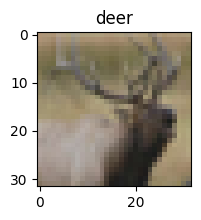

In [73]:
plt.figure(figsize=(2,2))
indx = np.random.choice(range(50000))
plt.imshow(X_train[indx])
plt.title(labels[y_train[indx][0]])
plt.show()

# PREPROCESSING



Creo una funzione per:
- rimuovere le labels "ship" e "airplane" perchè il task si riferisce a strade per aree urbane
- unire in un unica labels "automobile" e "truck" essendo entrambi veicoli presenti in aree urbane

In [74]:
def filter_and_remap(X, y):
    filtered_X = []
    filtered_y = []
    for img, label in zip(X, y):
        label = label[0]
        if label == 0 or label == 8:
            continue
        if label == 9:
            label = 1
        binary_label = 0 if label == 1 else 1
        filtered_X.append(img)
        filtered_y.append(binary_label)
    return np.array(filtered_X), np.array(filtered_y)

In [75]:
X_train, y_train = filter_and_remap(X_train, y_train)
X_test, y_test = filter_and_remap(X_test, y_test)

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(40000, 32, 32, 3) (40000,)
(8000, 32, 32, 3) (8000,)


Plottaggio di 4 immagini casuali con relative etichette

In [76]:
def plot_random_images_grid(x, y, rows=2, cols=2):
    n = rows * cols
    indices = np.random.choice(len(x), n, replace=False)
    fig, axs = plt.subplots(rows, cols, figsize=(cols * 3, rows * 3))
    axs = axs.flatten()
    for i, idx in enumerate(indices):
        img = x[idx]
        if img.min() < 0:
            img = (img + 1) / 2
        if img.max() > 1:
            img = img / 255.0

        label = 'automobile/truck' if y[idx] == 0 else 'animale'
        axs[i].imshow(img)
        axs[i].set_title(f"{label}")
        axs[i].axis('off')
    plt.tight_layout()
    plt.show()

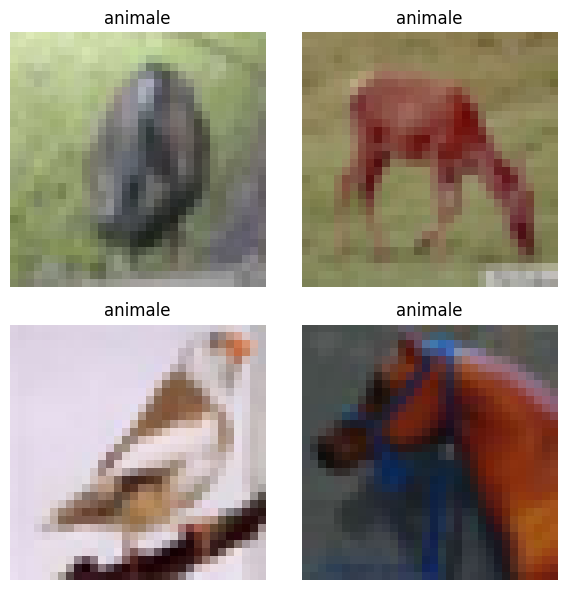

In [77]:
plot_random_images_grid(X_train, y_train, rows=2, cols=2)

Funzioni per verificare se ci sono nan nel dataset

In [78]:
def check_for_nan(x):
    nan_count = np.isnan(x).sum()
    if nan_count > 0:
        print(f"Avviso: trovati {nan_count} valori NaN nelle immagini")
    else:
        print("Nessun valore NaN trovato nelle immagini")

def check_labels_for_nan(y):
    nan_count = np.isnan(y).sum()
    if nan_count > 0:
        print(f"Avviso: trovati {nan_count} valori NaN nelle etichette")
    else:
        print("Nessun valore NaN trovato nelle etichette")

Funzione per verificare il bilanciamento del dataset

In [79]:
def check_class_balance(y):
    unique, counts = np.unique(y, return_counts=True)
    for u, c in zip(unique, counts):
        label = 'automobile/truck' if u == 0 else 'animale'
        print(f"Classe {label}: {c} esempi ({c / len(y) * 100:.2f}%)")

In [80]:
check_for_nan(X_train)
check_labels_for_nan(y_train)
check_class_balance(y_train)
print('\n')
check_for_nan(X_test)
check_labels_for_nan(y_test)
check_class_balance(y_test)

Nessun valore NaN trovato nelle immagini
Nessun valore NaN trovato nelle etichette
Classe automobile/truck: 10000 esempi (25.00%)
Classe animale: 30000 esempi (75.00%)


Nessun valore NaN trovato nelle immagini
Nessun valore NaN trovato nelle etichette
Classe automobile/truck: 2000 esempi (25.00%)
Classe animale: 6000 esempi (75.00%)


Essendo sbilanciato applicheremo una data augmentation per rendere  equilibrate le classi

In [81]:

auto_images = X_train[y_train == 0]
auto_labels = y_train[y_train == 0]

datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

num_animals = np.sum(y_train == 1)
num_needed = num_animals - len(auto_images)

augmented_images = []
augmented_labels = []
for batch in datagen.flow(auto_images, auto_labels, batch_size=32, shuffle=False):
    augmented_images.extend(batch[0])
    augmented_labels.extend(batch[1])
    if len(augmented_images) >= num_needed:
        break

augmented_images = np.array(augmented_images[:num_needed])
augmented_labels = np.array(augmented_labels[:num_needed])

X_train_balanced = np.concatenate((X_train, augmented_images))
y_train_balanced = np.concatenate((y_train, augmented_labels))

print(f"Nuovo shape immagini: {X_train_balanced.shape}")
print(f"Nuovo shape etichette: {y_train_balanced.shape}")
print(f"Automobili/truck: {np.sum(y_train_balanced == 0)}")
print(f"Animali: {np.sum(y_train_balanced == 1)}")


Nuovo shape immagini: (60000, 32, 32, 3)
Nuovo shape etichette: (60000,)
Automobili/truck: 30000
Animali: 30000


Funzione per plottare 4 immagini casuali con relative etichette create con data augmentation

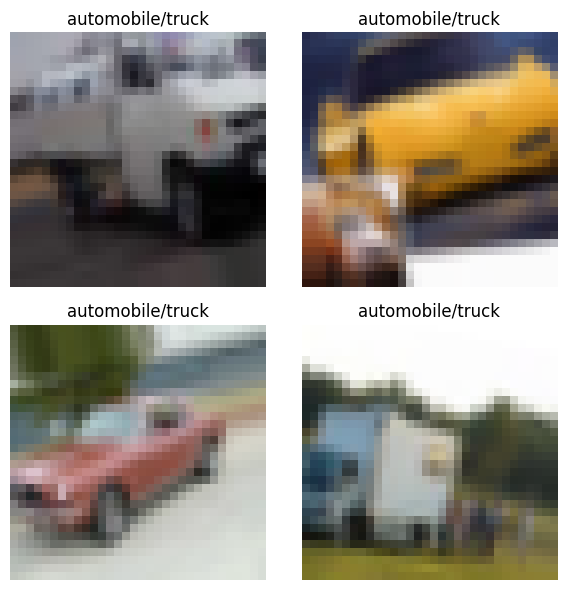

In [82]:
def plot_augmented_images(augmented_images, augmented_labels, rows=2, cols=2):
    n = rows * cols
    fig, axs = plt.subplots(rows, cols, figsize=(cols * 3, rows * 3))
    axs = axs.flatten()
    indices = np.random.choice(len(augmented_images), n, replace=False)
    for i, idx in enumerate(indices):
        img = augmented_images[idx]
        if img.min() < 0:
            img = (img + 1) / 2
        if img.max() > 1:
            img = img / 255.0
        label = 'automobile/truck'
        axs[i].imshow(img)
        axs[i].set_title(f"{label}")
        axs[i].axis('off')
    plt.tight_layout()
    plt.show()

plot_augmented_images(augmented_images, augmented_labels, rows=2, cols=2)

In [83]:
clear_session()
model = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    tf.keras.layers.MaxPooling2D((2,2)),
    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2,2)),
    tf.keras.layers.Conv2D(128, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2,2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dropout(0.4),
    tf.keras.layers.Dense(1, activation='sigmoid')])

In [84]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy'])

In [85]:
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history = model.fit(
    X_train_balanced, y_train_balanced,
    epochs=30,
    batch_size=64,
    validation_data=(X_test, y_test),
    callbacks=[early_stop]
)

Epoch 1/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.8151 - loss: 0.7797 - val_accuracy: 0.9392 - val_loss: 0.1558
Epoch 2/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9262 - loss: 0.1885 - val_accuracy: 0.9366 - val_loss: 0.1781
Epoch 3/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9409 - loss: 0.1545 - val_accuracy: 0.9495 - val_loss: 0.1371
Epoch 4/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9472 - loss: 0.1379 - val_accuracy: 0.9480 - val_loss: 0.1427
Epoch 5/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9526 - loss: 0.1242 - val_accuracy: 0.9604 - val_loss: 0.1131
Epoch 6/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9586 - loss: 0.1082 - val_accuracy: 0.9551 - val_loss: 0.1181
Epoch 7/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9632 - loss: 0.0958 - val_accuracy: 0.9449 - val_loss: 0.1525
Epoch 8/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9660 - loss: 0.0874 - val_accuracy: 0

# Prova con Transfer Learning

In [86]:
tf_model = ResNet50(weights = 'imagenet', include_top = False)

In [87]:
x = tf_model.output
compact = GlobalAveragePooling2D()(x)
extractor = Model(inputs=tf_model.input,outputs=compact)

In [88]:
feat_train = extractor.predict(X_train_balanced)
feat_test = extractor.predict(X_test)
feat_train.shape, feat_test.shape

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 7ms/step
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step


((60000, 2048), (8000, 2048))

In [89]:
logreg = LogisticRegression()
logreg.fit(feat_train, y_train_balanced)

LogisticRegression()

In [90]:
print('train accuracy',logreg.score(feat_train,y_train_balanced))
print('test accuracy',logreg.score(feat_test,y_test))

train accuracy 0.9442666666666667
test accuracy 0.923875


#Valutazione del modello


## Grafici di accuracy e log_loss

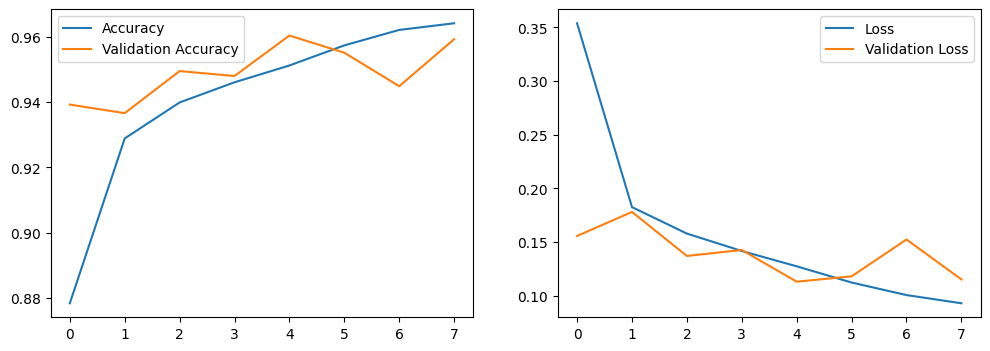

In [91]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()

L’apprendimento è stabile e controllato. Il modello generalizza bene sul test set. Non sembra esserci overfitting

## Report di classificazione

In [92]:
y_pred = (model.predict(X_test) > 0.5).astype(int)
print(classification_report(y_test, y_pred))

250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
              precision    recall  f1-score   support

           0       0.91      0.93      0.92      2000
           1       0.98      0.97      0.97      6000

    accuracy                           0.96      8000
   macro avg       0.94      0.95      0.95      8000
weighted avg       0.96      0.96      0.96      8000



il modello ha prestazioni elevate sia nel riconoscimento degli animali che dei veicoli avendo un accuracy media di 0.96

## Matrice di confusione

In [93]:
y_pred_cm = (model.predict(X_test) > 0.5).astype(int)
print(confusion_matrix(y_test, y_pred_cm))

250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
[[1861  139]
 [ 178 5822]]


Il modello tende a preferire (leggermente) la classe animale, come visto dal minor errore su questa classe rispetto alla classe auto/truck.

Visualizzazione delle classificazioni errate

250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


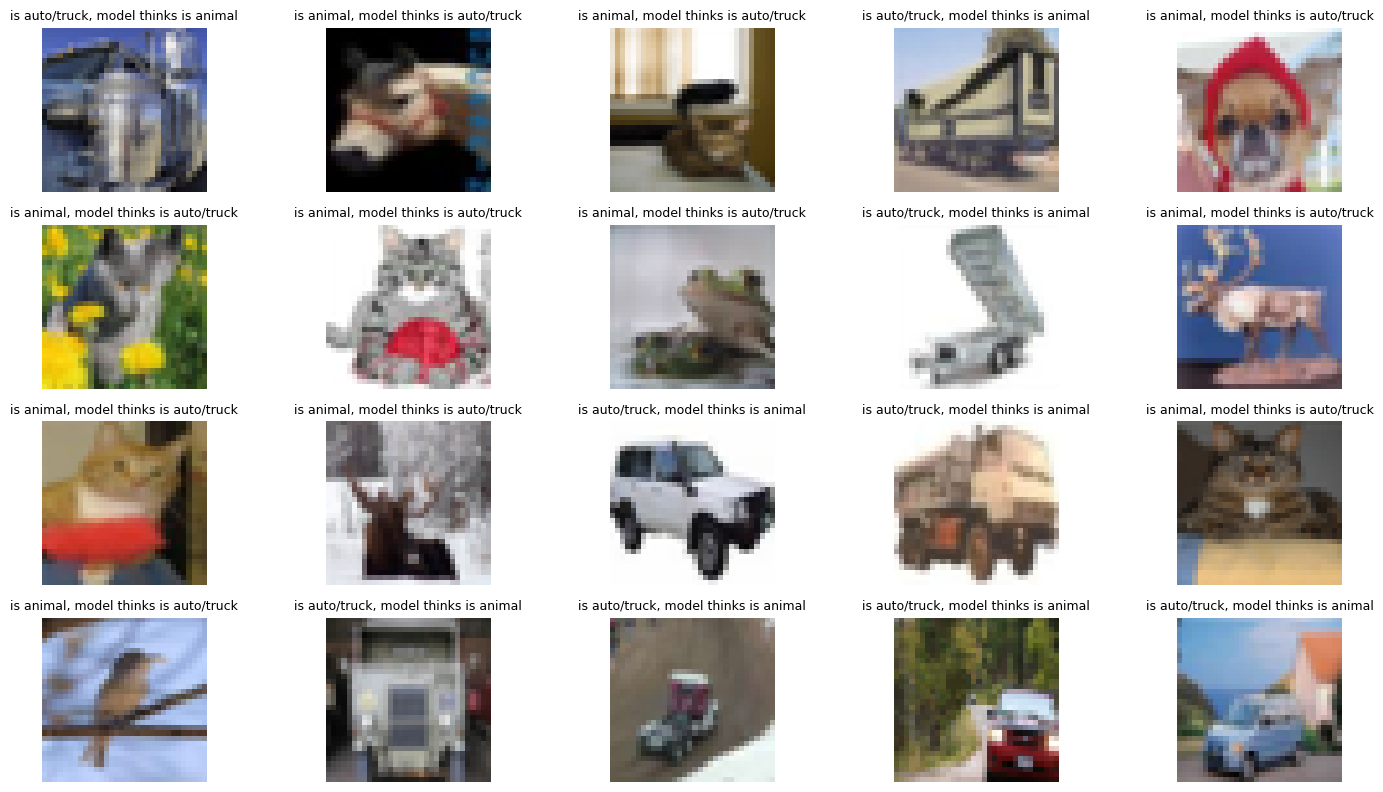

In [94]:
label_map = {0: "auto/truck", 1: "animal"}

n_images = 20
rows, cols = 4, 5
plt.figure(figsize=(15, 8))
y_pred = (model.predict(X_test) > 0.5).astype(int).flatten()
error_idx = np.where(y_pred != y_test)[0]

for i in range(n_images):
    idx = error_idx[i]
    true_label = y_test[idx]
    pred_label = y_pred[idx]
    title_text = f"is {label_map[true_label]}, model thinks is {label_map[pred_label]}"
    plt.subplot(rows, cols, i+1)
    plt.imshow(X_test[idx])
    plt.title(title_text, fontsize=9)
    plt.axis('off')

plt.tight_layout(pad=1.0)
plt.show()

#Considerazioni finali

La matrice di confusione mostra che il modello tende a scambiare la classe “automobile/truck” più spesso con “animale” (191 errori) rispetto al contrario (109 errori).
Questo indica che nei casi dubbi (immagini meno chiare, veicoli poco visibili, tonalità e forme simili a quelle degli animali) il modello può confondere facilmente le classi.
L’errore è maggiore per la classe minoritaria ed è probabilmente dovuto alla data augmentation.
I camion/automobili vengono confusi principalmente quando appaiono in pose insolite, con colori meno tipici, o sono parzialmente coperti (a volte alcune texture/fondi imitano pattern tipici degli animali).

Ad ogni modo Le prestazioni del modello rimangono alte e stabili anche dopo una lunga fase di training, con valori di accuratezza, precisione e recall molto elevati sia su train che su test.